# Equity Implied Correlation Analysis

The overall goal of this notebook is to analyze the following

Conditioning Returns under different implied correlation structures
1. Examining the Trend Following Equity Indices
2. Examining SPX Trend Following with CBOE Trend Following

# Packages

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from   sklearn.decomposition import PCA

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Path Management and Data

In [2]:
misc_path      = os.getcwd()
research_path  = os.path.abspath(os.path.join(misc_path, ".."))
repo_path      = os.path.abspath(os.path.join(research_path, ".."))
data_path      = os.path.join(repo_path, "data")
trend_idx_path = os.path.join(data_path, "TrendIndices")
fut_path       = os.path.join(data_path, "FuturesData")

In [3]:
trend_px_path     = os.path.join(trend_idx_path, "RawTrendIndices.parquet")
trend_ticker_path = os.path.join(trend_idx_path, "TrendIndicesGuide.xlsx")

df_trend_tickers = (pd.read_excel(
    io = trend_ticker_path, sheet_name = "TrendIndices").
    rename(columns = {"Asset Class": "asset_class"}).
    query("asset_class == 'Equity'").
    query("Currency == 'USD'").
    query("Holding == 'Multi Period'").
    dropna()
    [["Ticker", "Name", "Holding", "PlotName"]].
    melt(id_vars = "Ticker").
    rename(columns = {"Ticker": "ticker"}).
    assign(
        ticker   = lambda x: x.ticker.str.split(" ").str[0],
        variable = lambda x: x.variable.str.lower()).
    pivot(index = "ticker", columns = "variable", values = "value").
    reset_index())

trend_tickers = df_trend_tickers.ticker.drop_duplicates().sort_values().to_list()

In [4]:
df_index_trend = (pd.read_parquet(
    path = trend_px_path, engine = "pyarrow").
    assign(ticker = lambda x: x.security.str.split(" ").str[0]).
    query("ticker == @trend_tickers").
    drop(columns = ["security"]))

In [5]:
misc_data_path = os.path.join(data_path, "MiscData")
cboe_path      = os.path.join(misc_data_path, "CleanedCBOEImpliedCorrelation.parquet")
bbg_path       = os.path.join(misc_data_path, "CleanedImpliedRealCorrelation.parquet")

df_cboe = (pd.read_parquet(
    path   = cboe_path, 
    engine = "pyarrow").
    drop(columns = ["value"]).
    rename(columns = {
        "Date"     : "date",
        "clean_val": "value"}).
    assign(variable = lambda x: x.variable.str.split(" ").str[0]))

df_bbg = (pd.read_parquet(
    path   = bbg_path, 
    engine = "pyarrow").
    rename(columns = {"Date": "date"}).
    drop(columns = ["value"]).
    rename(columns = {"clean_val": "value"}))

In [6]:
path = os.path.join(misc_data_path, "ImpliedCorrelationTickerGuide.xlsx")

df_cboe_tickers = (pd.read_excel(
    io = path, sheet_name = "CBOEGuide").
    rename(columns = {"Ticker": "ticker"}).
    melt(id_vars = "ticker").
    assign(
        ticker   = lambda x: x.ticker.str.split(" ").str[0],
        variable = lambda x: x.variable.str.replace(" ", "_").str.lower()).
    pivot(index = "ticker", columns = "variable", values = "value").
    reset_index())

In [7]:
trend_idx_renamer = (df_trend_tickers.set_index(
    "ticker").
    plotname.
    to_dict())

In [8]:
three_dict = (df_cboe_tickers.query(
    "window == 90").
    assign(ticker = lambda x: x.ticker.str.split(" ").str[0]).
    assign(tmp = "constant_tenor")
    [["tmp", "ticker"]].
    groupby("tmp").
    agg(list).
    ticker.
    to_dict())

fifty_dict = (df_cboe_tickers.query(
    "delta == 50").
    assign(ticker = lambda x: x.ticker.str.split(" ").str[0]).
    assign(tmp = "constant_delta")
    [["tmp", "ticker"]].
    groupby("tmp").
    agg(list).
    ticker.
    to_dict())

exog_dict = {**three_dict, **fifty_dict}

# Examining the Data

Two indices are used: the Bloomberg Equity Trend Indices and the Barclays Buraschi Equity Trend Index, both of which track equity trend-following strategies.

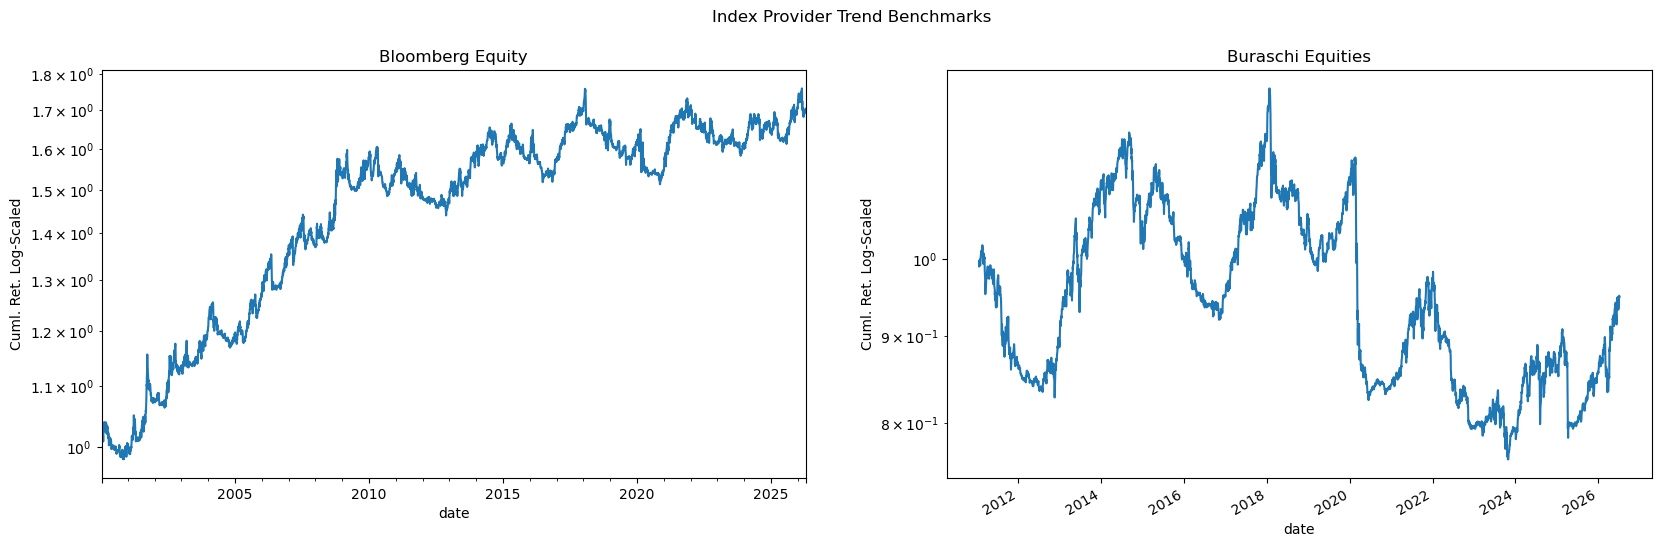

In [9]:
tickers   = df_index_trend.ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(tickers), figsize = (20,6))

for ticker, ax in zip(tickers, axes.flatten()):
    
    (df_index_trend.query(
        "ticker == @ticker").
        set_index("date").
        sort_index()
        [["PX_LAST"]].
        pct_change().
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            legend = False,
            logy   = True,
            ax     = ax,
            title  = trend_idx_renamer[ticker],
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Index Provider Trend Benchmarks")
plt.show()

The CBOE S&P 500 implied correlation indices are used as explanatory variables. CBOE provides implied correlation measures for the 50$\Delta$ option across multiple maturities. For the 3-month maturity, implied correlation is available across several option deltas, including 10$\Delta$, 30$\Delta$, 50$\Delta$, 70$\Delta$, and 90$\Delta$.

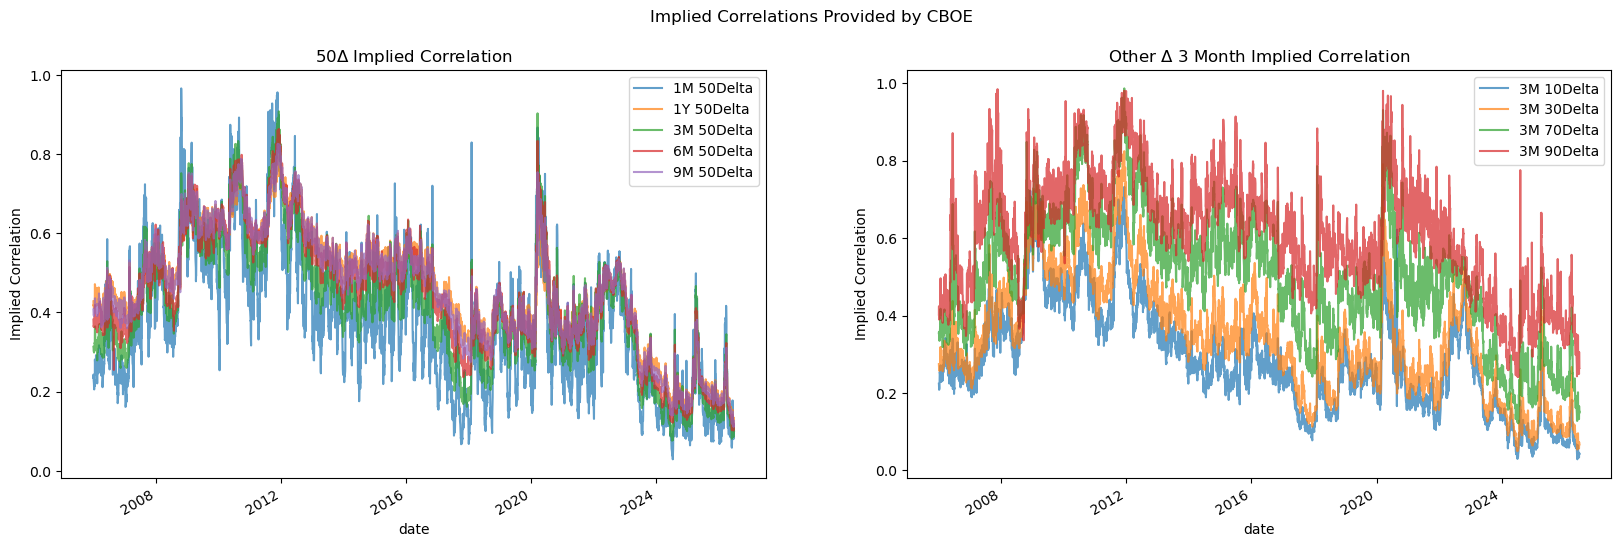

In [10]:
df_tmp = (df_cboe.rename(columns = {
    "variable": "ticker"}).
    merge(right = df_cboe_tickers, how = "inner", on = ["ticker"]))

fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_tmp.query(
    "delta == 50").
    rename(columns = {"plot_name": ""}).
    pivot(index = "date", columns = "", values = "value").
    plot(
        ax     = axes[0],
        alpha  = 0.7,
        ylabel = "Implied Correlation",
        title  = "50$\Delta$ Implied Correlation"))

(df_tmp.query(
    "delta != 50").
    rename(columns = {"plot_name": ""}).
    pivot(index = "date", columns = "", values = "value").
    plot(
        ax     = axes[1],
        alpha  = 0.7,
        ylabel = "Implied Correlation",
        title  = r"Other $\Delta$ 3 Month Implied Correlation"))

fig.suptitle("Implied Correlations Provided by CBOE")
plt.show()

# Multi-Day Trend OLS Driver

Although the CBOE implied correlation index is directly linked to S&P 500 returns, while the Equity Trend Indices represent a combination of an unspecified set of equity futures, the comparison is not exact. However, the implied correlation measures provide a useful starting point for evaluating the relationship between equity correlation dynamics and trend-following returns.

Regressions are estimated for the following indices:
1. BSLEQT Index — Bloomberg Equity Trend Index
2. BXIIBATE Index — Buraschi Barclays Adaptive Trend Index (Equities)

Two sets of endogenous variables are considered:
1. The full term structure of 50$\Delta$ implied correlation
2. All available deltas for the 3-month implied correlation

Three transformations are applied to the implied correlation variables:
1. 30-day exponentially weighted z-score of the implied correlation level
2. First differences of implied correlation values

All explanatory variables are lagged to ensure that the analysis evaluates their predictive power and avoids look-ahead bias.

In [11]:
def get_prep_corr(df_cboe: pd.DataFrame, lag: int = 0) -> pd.DataFrame:

    df_wider = (df_cboe.pivot(
        index = "date", columns = "variable", values = "value"))
    
    window = 30
    
    df_zscore = (df_wider.apply(
        lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
        shift(lag).
        reset_index().
        melt(id_vars = ["date"]).
        assign(var_type = "z_score"))
    
    df_diff = (df_wider.diff().shift().reset_index().melt(
        id_vars = "date", value_name = "value").
        assign(var_type = "diff_val"))

    df_out = pd.concat([df_zscore, df_diff])
    return df_out

df_exog     = get_prep_corr(df_cboe)
df_lag_exog = get_prep_corr(df_cboe, 1)

In [12]:
df_trend_rtn = (df_index_trend.
    pivot(index = "date", columns = "ticker", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna())

df_combined = (df_exog.merge(
    right = df_trend_rtn, how = "inner", on = ["date"]).
    assign(group_var = lambda x: x.var_type + " " + x.ticker))

In [13]:
def _get_ols(df: pd.DataFrame, exog_dict: dict) -> pd.DataFrame: 

    df_tmp = (df.reset_index().pivot(
        index = ["date", "rtn"], columns = "variable", values = "value").
        reset_index().
        set_index("date").
        ffill().
        dropna())

    df_out = pd.DataFrame()
    
    for key in exog_dict.keys():

        model = (sm.OLS(
            endog = df_tmp.rtn,
            exog  = sm.add_constant(df_tmp[exog_dict[key]])).
            fit())

        df_param  = model.params.to_frame(name = "param").reset_index()
        df_pvalue = model.pvalues.to_frame(name = "p_value").reset_index()
        df_stat   = model.tvalues.to_frame(name = "t_stat").reset_index()

        df_add = (df_param.merge(
            right = df_pvalue, how = "inner", on = ["index"]).
            merge(right = df_stat, how = "inner", on = ["index"]).
            assign(model = key))
        
        df_out = pd.concat([df_out, df_add])

    return df_out

df_params = (df_combined.groupby(
    "group_var").
    apply(_get_ols, exog_dict).
    reset_index().
    drop(columns = ["level_1"]))

In [14]:
trend_mapper = (df_trend_tickers.set_index(
    "ticker").
    plotname.
    to_dict())

signal_mapper = {
    "diff_val": "Differenced",
    "z_score" : "Z-Score"}

model_renamer = {
    "constant_tenor": "Const Tenor",
    "constant_delta": r"Const $\Delta$"}

In [15]:
df_param_tmp = (df_params.assign(
    ticker = lambda x: x.group_var.str.split(" ").str[1].map(trend_mapper),
    signal = lambda x: x.group_var.str.split(" ").str[0].map(signal_mapper)).
    drop(columns = ["group_var"]))

Now run a regresion of the values (not-lagged) as a way to test their factor exposure. The regression are done controlling for either constant tenor 3 Month or constant Delta 50$\Delta$.

In [16]:
(df_param_tmp.assign(
    name = lambda x: x.ticker + " " + x.model.map(model_renamer)).
    drop(columns = ["ticker", "model"]).
    melt(id_vars = ["name", "signal", "index"]).
    rename(columns = {
        "variable": ""}).
    pivot(index = ["name", "index"], columns = ["", "signal"], values = "value"))

param               p_value  \
signal                                  Differenced   Z-Score Differenced   
name                             index                                      
Bloomberg Equity Const $\Delta$  COR1M    -0.004858 -0.000317    0.039986   
                                 COR1Y     0.014155 -0.000151    0.030228   
                                 COR3M    -0.001221 -0.000286    0.808932   
                                 COR6M    -0.002342 -0.000240    0.707762   
                                 COR9M    -0.013831  0.000128    0.068941   
                                 const     0.000049  0.000003    0.278627   
Bloomberg Equity Const Tenor     COR10D    0.000749  0.000312    0.784169   
                                 COR30D   -0.008904 -0.000538    0.140284   
                                 COR3M    -0.007985  0.000037    0.191976   
                                 COR70D    0.011037 -0.000446    0.019603   
                                 COR90D   -0.007633 -0.000155    0.000034   
                                 const     0.000049  0.000006    0.274553   
Buraschi Equities Const $\Delta$ COR1M    -0.005085 -0.000545    0.317002   
                                 COR1Y     0.008041 -0.000410    0.513658   
                                 COR3M    -0.041292 -0.000963    0.000177   
                                 COR6M     0.012327 -0.000375    0.393619   
                                 COR9M    -0.003690  0.000073    0.794973   
                                 const    -0.000034 -0.000211    0.710600   
Buraschi Equities Const Tenor    COR10D   -0.000179  0.000813    0.976070   
                                 COR30D    0.031000 -0.000535    0.021686   
                                 COR3M    -0.044097 -0.001847    0.001068   
                                 COR70D   -0.017966  0.000002    0.072923   
                                 COR90D    0.002402 -0.000466    0.539896   
                                 const    -0.000035 -0.000185    0.696655   

                                                       t_stat            
signal                                    Z-Score Differenced   Z-Score  
name                             index                                   
Bloomberg Equity Const $\Delta$  COR1M   0.000120   -2.054422 -3.849475  
                                 COR1Y   0.329991    2.167689 -0.974225  
                                 COR3M   0.054356   -0.241816 -1.924429  
                                 COR6M   0.155867   -0.374884 -1.419319  
                                 COR9M   0.554680   -1.819188  0.590801  
                                 const   0.938770    1.083525  0.076819  
Bloomberg Equity Const Tenor     COR10D  0.001363    0.273905  3.204078  
                                 COR30D  0.013941   -1.474963 -2.459638  
                                 COR3M   0.903312   -1.304927  0.121484  
                                 COR70D  0.068539    2.334597 -1.821832  
                                 COR90D  0.100140   -4.148212 -1.644476  
                                 const   0.885941    1.092755  0.143449  
Buraschi Equities Const $\Delta$ COR1M   0.000893   -1.000768 -3.324887  
                                 COR1Y   0.180588    0.653214 -1.339191  
                                 COR3M   0.004134   -3.753165 -2.869477  
                                 COR6M   0.445828    0.853168 -0.762467  
                                 COR9M   0.870834   -0.259876  0.162610  
                                 const   0.016440   -0.371078 -2.400064  
Buraschi Equities Const Tenor    COR10D  0.000871   -0.029998  3.331661  
                                 COR30D  0.372499    2.296767 -0.891906  
                                 COR3M   0.011946   -3.274362 -2.514932  
                                 COR70D  0.997181   -1.793803  0.003534  
                                 COR90D  0.015813    0.613025 -2.414281  
                                 const   0

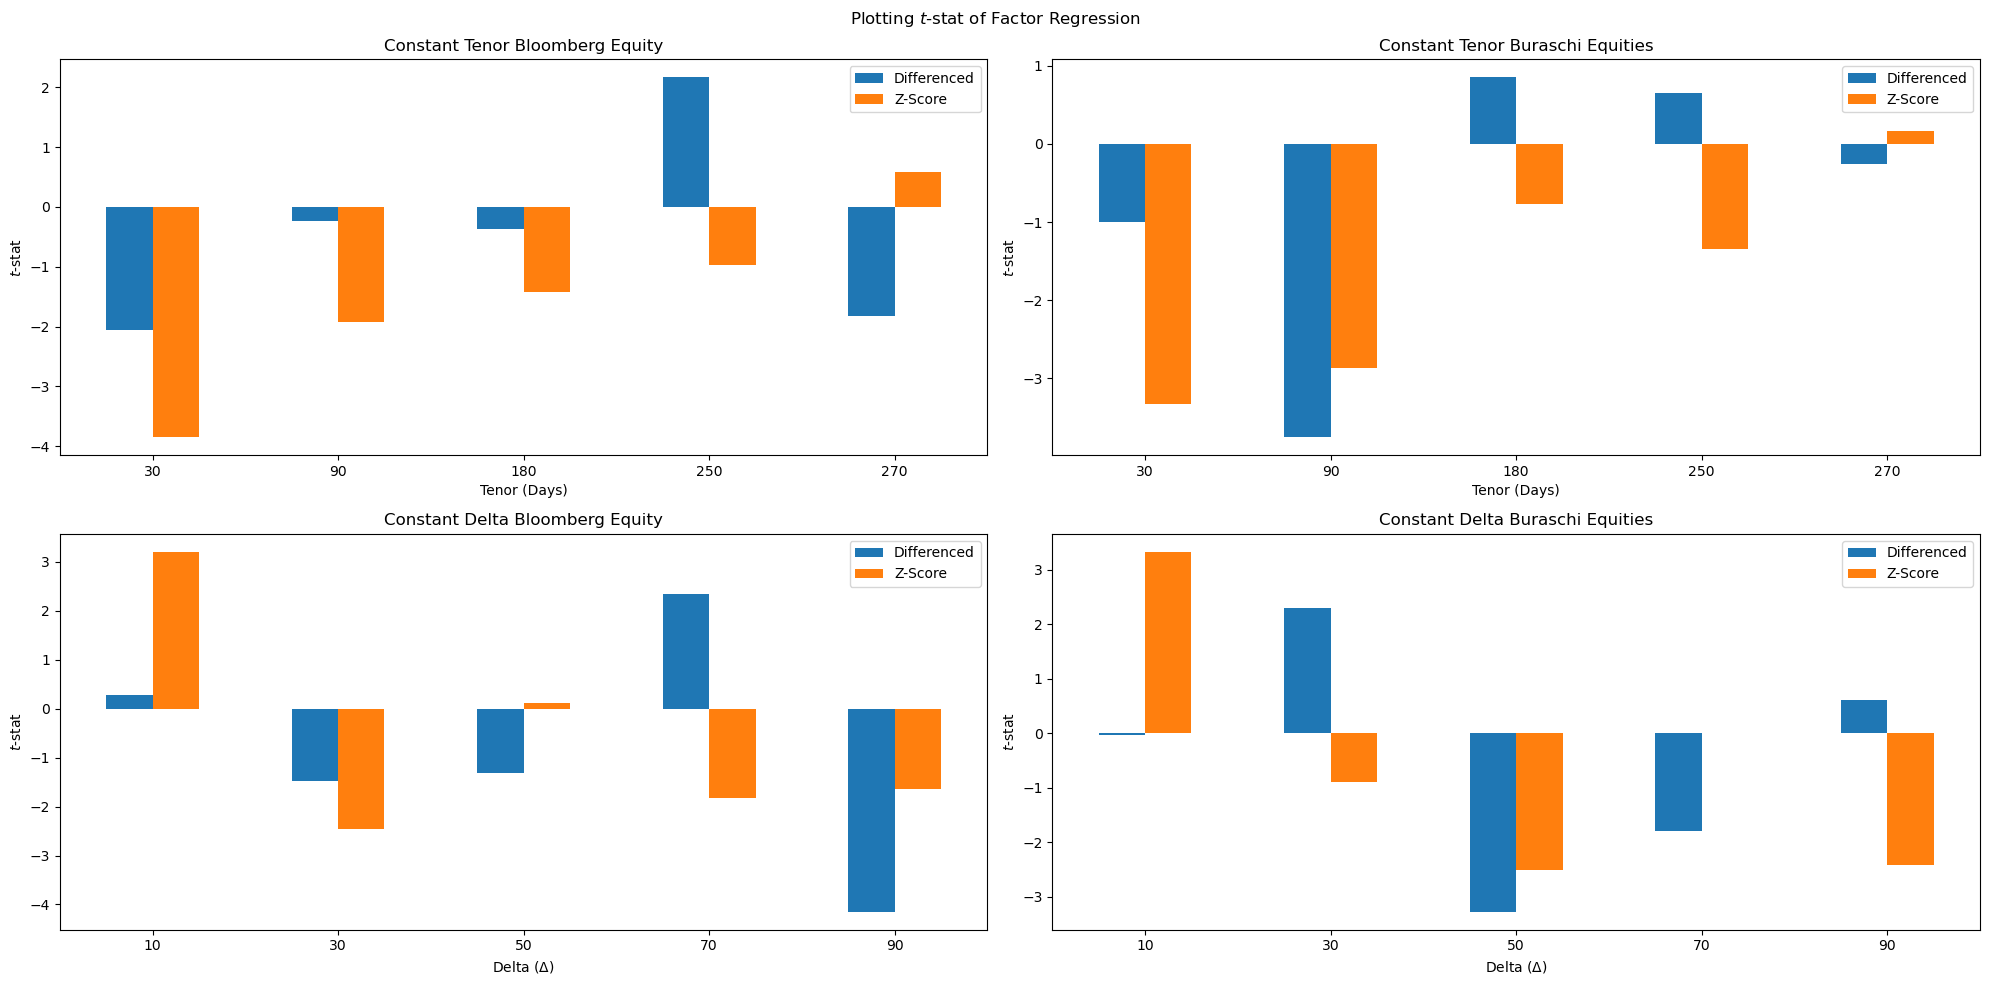

In [17]:
df_stat = (df_param_tmp.query(
    "index != 'const'").
    drop(columns = ["param", "p_value"]).
    assign(group_var = lambda x: x.model + "-" + x.ticker))

group_vars = df_stat.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 2, nrows = len(group_vars) // 2, figsize = (20,10))

for group_var, ax in zip(group_vars, axes.flatten()): 

    group_selector, _ = group_var.split("-")

    if group_selector == "constant_delta":
        
        mapper = (df_cboe_tickers.set_index(
            "ticker").
            window.
            to_dict())

        xlabel     = "Tenor (Days)"
        front_name = "Constant Tenor"
    
    else:
        
        mapper = (df_cboe_tickers.set_index(
            "ticker").
            delta.
            to_dict())

        xlabel     = "Delta ($\Delta$)"
        front_name = "Constant Delta"
    
    (df_stat.query(
        "group_var == @group_var").
        rename(columns = {"index": "corr_ticker"}).
        assign(tmp = lambda x: x.corr_ticker.map(mapper)).
        rename(columns = {"signal": ""}).
        pivot(index = "tmp", columns = "", values = "t_stat").
        plot(
            ylabel = r"$t$-stat",
            ax     = ax, 
            kind   = "bar",
            rot    = 0,
            xlabel = xlabel,
            title  = front_name + " " + group_var.split("-")[-1]))

fig.suptitle("Plotting $t$-stat of Factor Regression")
plt.tight_layout()

# Examining SPX Trend Following

Now we'll examine specifically SPX trend following. For now we'll use JP Bouchaud approach (London/Euro approach) which uses a single 100d EWMA window.  

In [18]:
spx_path = os.path.join(fut_path, "PrepFuturesPX.parquet")
df_es    = (pd.read_parquet(
    path = spx_path, engine = "pyarrow").
    query("ticker == 'es1_index'")
    [["date", "adj_val"]].
    set_index("date").
    sort_index().
    rename(columns = {"adj_val": "px"}).
    assign(
        px_diff    = lambda x: x.px.diff(),
        px_dt      = lambda x: x.px_diff / x.px_diff.ewm(span = 10, adjust = False).std(),
        signal     = lambda x: x.px_dt.ewm(span = 100, adjust = False).mean().shift(),
        px_rtn     = lambda x: x.px.pct_change(),
        signal_rtn = lambda x: np.sign(x.signal) * x.px_rtn,
        vol_rtn    = lambda x: x.signal_rtn * (0.1 / (x.signal_rtn.ewm(span = 100, adjust = False).std() * np.sqrt(252)))))

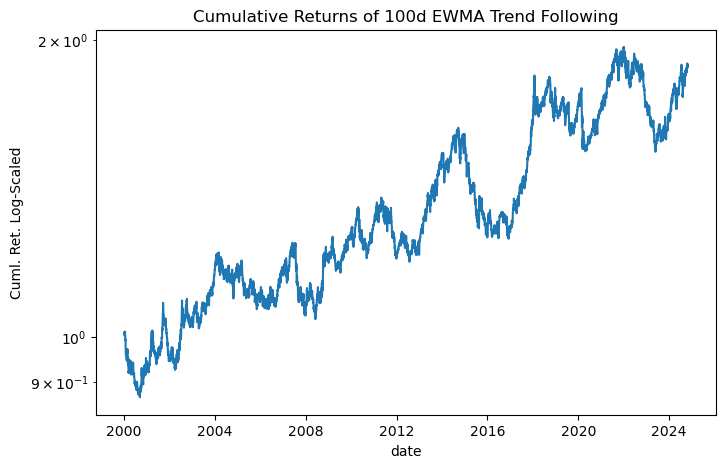

In [19]:
(df_es[
    ["vol_rtn"]].
    dropna().
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        logy    = True,
        legend  = False,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of 100d EWMA Trend Following",
        figsize = (8,5)))

plt.show()

In [20]:
df_spx_trend = (df_es[
    ["vol_rtn"]].
    rename(columns = {"vol_rtn": "spx_trend"}))

In [21]:
def _run_regression(df: pd.DataFrame,
                    endog_dict: dict,
                    min_obs: int = 60) -> pd.DataFrame:

    df_out = pd.DataFrame()

    for key, tickers in endog_dict.items():

        df_tmp = (
            df.assign(
                ticker=lambda x: x.variable.str.split(" ").str[0]
            )
            .query("ticker == @tickers")
            .reset_index()
            .pivot(
                index=["date", "spx_trend"],
                columns="ticker",
                values="value",
            )
            .dropna()
            .reset_index()
            .set_index("date")
            .sort_index()
        )

        y = df_tmp["spx_trend"]
        X = sm.add_constant(df_tmp[tickers])

        # -------------------
        # In-sample regression
        # -------------------
        model = sm.OLS(y, X).fit()

        is_pred = model.fittedvalues

        # -------------------
        # Expanding OOS regression
        # -------------------
        rols = RollingOLS(
            endog=y,
            exog=X,
            min_nobs=min_obs,
            expanding=True,
        ).fit()

        oos_pred = (X * rols.params.shift(1)).sum(axis=1)

        df_add = (
            df_tmp.assign(
                is_y_pred      = is_pred,
                is_signal_rtn  = lambda x: np.sign(x.is_y_pred) * x.spx_trend,
                oos_y_pred     = oos_pred,
                oos_signal_rtn = lambda x: np.sign(x.oos_y_pred) * x.spx_trend,
                name           = key,
            )[[
                "spx_trend",
                "is_y_pred",
                "is_signal_rtn",
                "oos_y_pred",
                "oos_signal_rtn",
                "name",
            ]]
        )

        df_out = pd.concat([df_out, df_add])

    return df_out


df_signal_rtn = (
    df_lag_exog.assign(
        date=lambda x: pd.to_datetime(x.date).dt.date
    )
    .merge(
        right=df_spx_trend,
        how="inner",
        on=["date"],
    )
    .dropna()
    .set_index("date")
    .groupby("var_type")
    .apply(_run_regression, exog_dict)
    .reset_index()
)

var_dict  = {"z_score": "Z-Score", "diff_val": "Differenced"}

In [22]:
df_avg = (df_signal_rtn.drop(
    columns = ["is_y_pred", "oos_y_pred"]).
    melt(id_vars = ["date", "var_type", "name", "spx_trend"], var_name = "model").
    assign(group_var = lambda x: x.var_type + " " + x.name).
    pivot(index = ["date", "model", "spx_trend"], columns = "group_var", values = "value").
    assign(avg_ex = lambda x: x.mean(axis = 1)).
    reset_index().
    set_index(["date", "model", "avg_ex"]).
    assign(avg_all = lambda x: x.mean(axis = 1)).
    reset_index().
    melt(id_vars = ["date", "model"]))

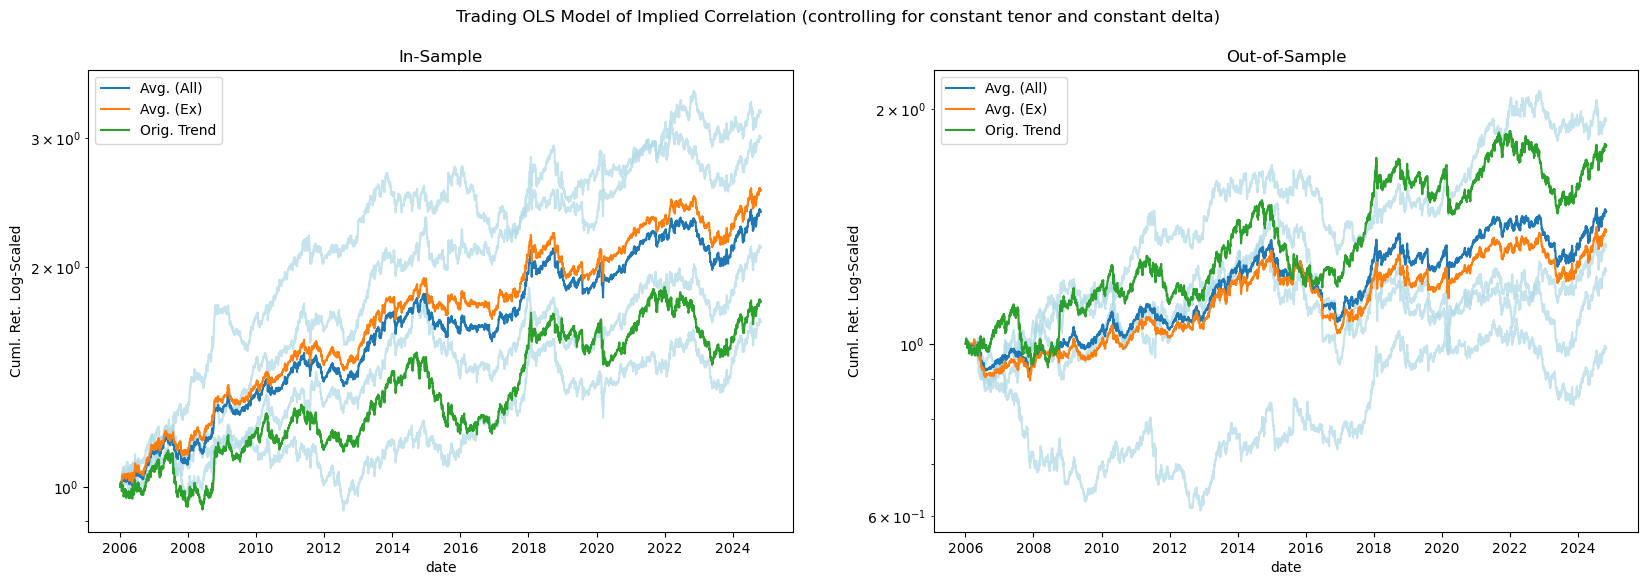

In [23]:
models    = df_avg.model.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(models), figsize = (20,6))

renamer = {
    "is_signal_rtn" : "In-Sample",
    "oos_signal_rtn": "Out-of-Sample"}

for model, ax in zip(models, axes.flatten()): 

    df_wider = (df_avg.query(
        "model == @model").
        rename(columns = {"group_var": ""}).
        pivot(index = "date", columns = "", values = "value"))

    tmp_cols = ["avg_all", "avg_ex", "spx_trend"]
    
    (df_wider.drop(
        columns = tmp_cols).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            alpha  = 0.7,
            ax     = ax,
            logy   = True,
            legend = False,
            color  = "lightblue"))
    
    (df_wider[
        tmp_cols].
        apply(lambda x: np.cumprod(1 + x)).
        rename(columns = {
            "avg_all"  : "Avg. (All)",
            "avg_ex"   : "Avg. (Ex)",
            "spx_trend": "Orig. Trend"}).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = renamer[model]))

fig.suptitle("Trading OLS Model of Implied Correlation (controlling for constant tenor and constant delta)")
plt.show()

In [24]:
replacer = {
    "avg_all"                : r"Avg (All)",
    "avg_ex"                 : r"Avg (Ex Orig)",
    "diff_val constant_delta": r"Diff Val Const. $\Delta$",
    "diff_val constant_tenor": r"Diff Val Const Tenor",
    "spx_trend"              : r"Original Trend",
    "z_score constant_delta" : r"Z-Score Const. $\Delta$",
    "z_score constant_tenor" : r"Z-Score Const. Tenor"}

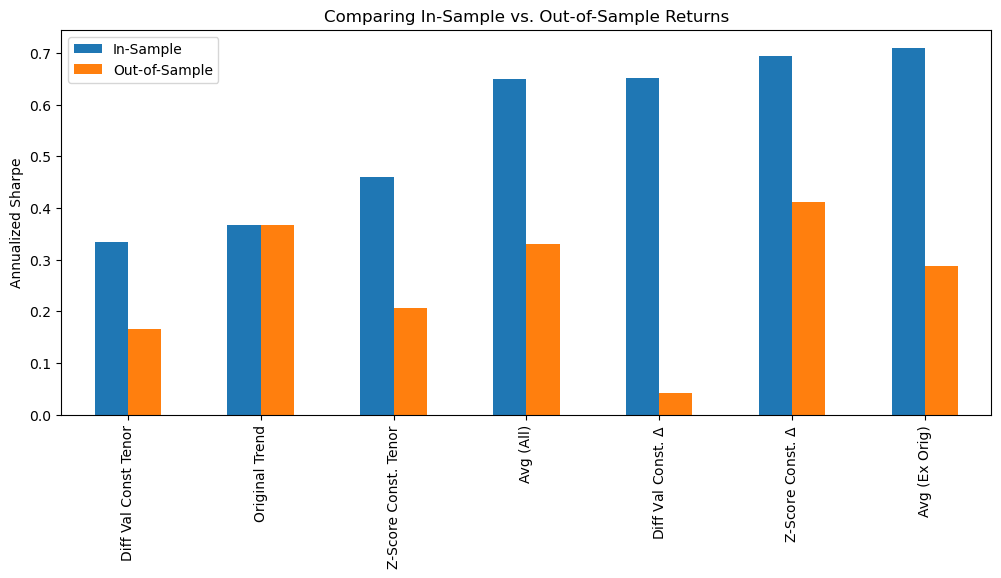

In [25]:
(df_avg.drop(
    columns = ["date"]).
    groupby(["model", "group_var"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"model": ""}).
    replace(replacer).
    pivot(index = "group_var", columns = "", values = "value").
    sort_values(["is_signal_rtn", "oos_signal_rtn"]).
    rename(columns = {
        "is_signal_rtn" : "In-Sample",
        "oos_signal_rtn": "Out-of-Sample"}).
    plot(
        kind    = "bar",
        figsize = (12,5),
        xlabel  = "",
        ylabel  = "Annualized Sharpe",
        title   = "Comparing In-Sample vs. Out-of-Sample Returns"))

plt.show()

# Examining the Principal Components

In [26]:
df_pc_exp, df_pc_val = pd.DataFrame(), pd.DataFrame()

for exog in exog_dict.keys():

    tickers  = exog_dict[exog]
    df_wider = (df_cboe.query(
        "variable == @tickers").
        pivot(index = "date", columns = "variable", values = "value").
        ffill())

    pca_model = PCA(n_components = len(df_wider.columns)).fit(df_wider)
    
    df_pc_exp_add = (pd.DataFrame({
        "exp_var": pca_model.explained_variance_ratio_}).
        reset_index().
        rename(columns = {"index": "PC"}).
        assign(
            name = exog,
            PC   = lambda x: x.PC + 1))

    df_pc_val_add = (pd.DataFrame(
        data    = pca_model.fit_transform(df_wider),
        columns = ["PC{}".format(i + 1) for i in range(len(df_wider.columns))],
        index   = df_wider.index).
        reset_index().
        melt(id_vars = "date").
        assign(name = exog))

    df_pc_exp = pd.concat([df_pc_exp, df_pc_exp_add])
    df_pc_val = pd.concat([df_pc_val, df_pc_val_add])

In [27]:
from sklearn.decomposition import PCA

df_pc_exp = pd.DataFrame()
df_pc_val = pd.DataFrame()
df_pc_loadings = pd.DataFrame()

for exog in exog_dict.keys():

    tickers = exog_dict[exog]

    df_wider = (
        df_cboe.query("variable == @tickers")
        .pivot(index="date", columns="variable", values="value")
        .ffill()
    )

    pca_model = PCA(n_components=len(df_wider.columns)).fit(df_wider)

    # Explained variance
    df_pc_exp_add = (
        pd.DataFrame({
            "PC": np.arange(1, len(df_wider.columns) + 1),
            "exp_var": pca_model.explained_variance_ratio_,
            "name": exog,
        })
    )

    # PC scores
    df_pc_val_add = (
        pd.DataFrame(
            pca_model.transform(df_wider),
            index=df_wider.index,
            columns=[f"PC{i}" for i in range(1, len(df_wider.columns) + 1)],
        )
        .reset_index()
        .melt(id_vars="date", var_name="PC", value_name="value")
        .assign(name=exog)
    )

    # Loadings
    df_pc_loadings_add = (
        pd.DataFrame(
            pca_model.components_,
            index=[f"PC{i}" for i in range(1, len(df_wider.columns) + 1)],
            columns=df_wider.columns,
        )
        .reset_index(names="PC")
        .melt(
            id_vars="PC",
            var_name="variable",
            value_name="loading",
        )
        .assign(name=exog)
    )

    df_pc_exp      = pd.concat([df_pc_exp, df_pc_exp_add], ignore_index=True)
    df_pc_val      = pd.concat([df_pc_val, df_pc_val_add], ignore_index=True)
    df_pc_loadings = pd.concat([df_pc_loadings, df_pc_loadings_add], ignore_index=True)

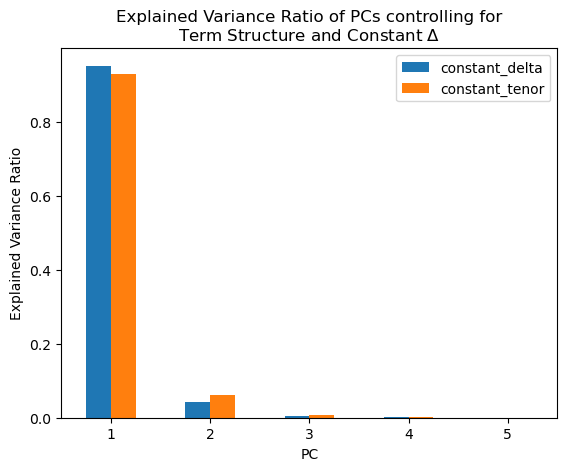

In [28]:
(df_pc_exp.rename(
    columns = {"name": ""}).
    pivot(index = "PC", columns = "", values = "exp_var").
    plot(
        rot    = 0,
        kind   = "bar",
        ylabel = "Explained Variance Ratio",
        title  = "Explained Variance Ratio of PCs controlling for\nTerm Structure and Constant $\Delta$"))

plt.show()

In [29]:
term_dict = (df_cboe_tickers.set_index(
    "ticker").
    window.
    to_dict())

delta_dict = (df_cboe_tickers.set_index(
    "ticker").
    delta.
    to_dict())

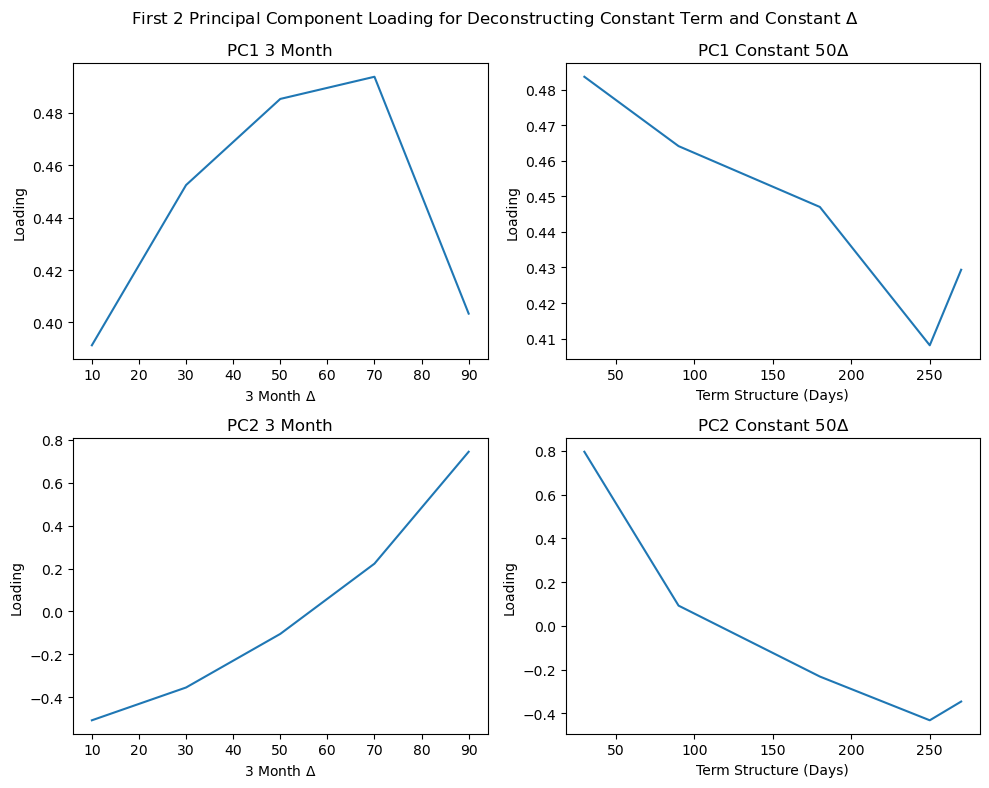

In [30]:
pcs = ["PC1", "PC2"]
fig, axes = plt.subplots(ncols = len(pcs), nrows = len(pcs), figsize = (10,8))

for i, pc in enumerate(pcs): 

    df_tmp = (df_pc_loadings.query(
        "PC == @pc"))

    (df_tmp.query(
        "name == 'constant_tenor'").
        assign(delta = lambda x: x.variable.map(delta_dict)).
        set_index("delta")
        [["loading"]].
        plot(
            ylabel = "Loading",
            legend = False,
            ax     = axes[i,0],
            title  = pc + " 3 Month",
            xlabel = "3 Month $\Delta$"))

    (df_tmp.query(
        "name == 'constant_delta'").
        assign(term = lambda x: x.variable.map(term_dict)).
        sort_values("term").
        set_index("term")
        [["loading"]].
        plot(
            ylabel = "Loading",
            legend = False,
            ax     = axes[i,1],
            xlabel = "Term Structure (Days)",
            title  = pc + " Constant 50$\Delta$"))

fig.suptitle("First 2 Principal Component Loading for Deconstructing Constant Term and Constant $\Delta$")
plt.tight_layout()

The first term structure is mostly positive therefore it just an *average*-like value across the term/$\Delta$ structure. The second component captures a more interseting dynamic of term structure steepning or skewness

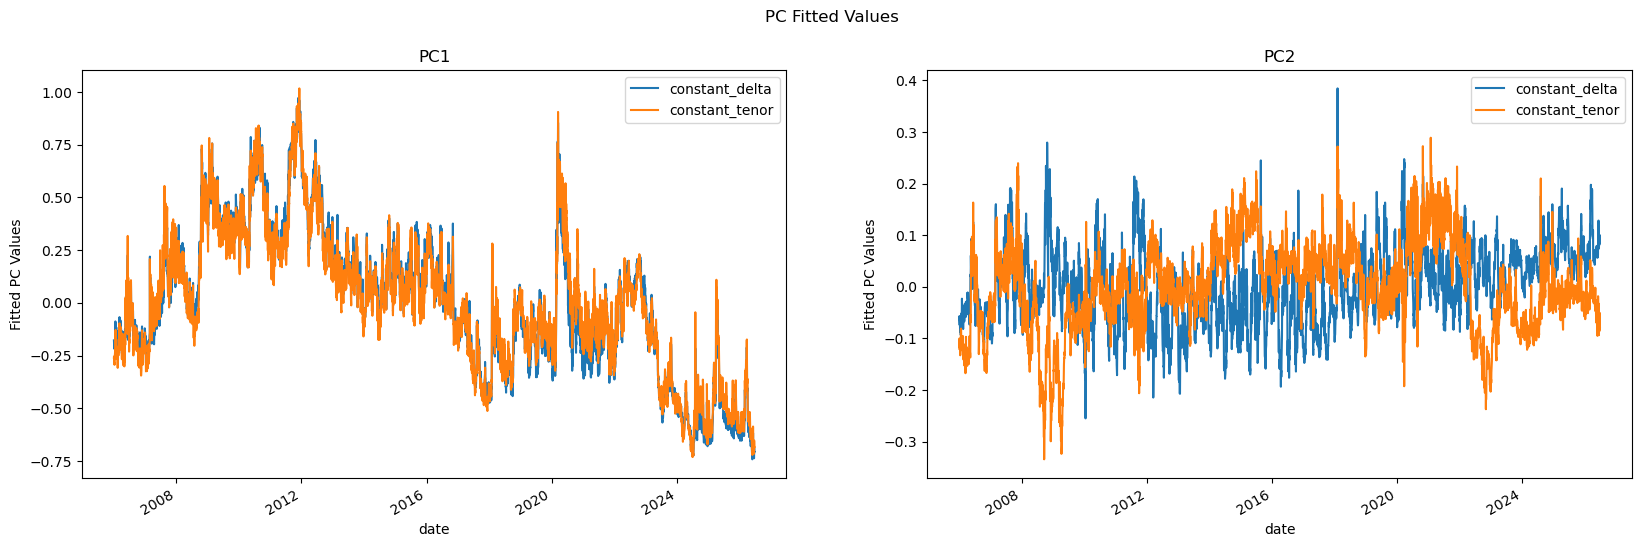

In [31]:
pcs = ["PC1", "PC2"]
fig, axes = plt.subplots(ncols = len(pcs), figsize = (20,6))

for pc, ax in zip(pcs, axes.flatten()):

    (df_pc_val.query(
        "PC == @pc").
        rename(columns = {"name": ""}).
        pivot(index = "date", columns = "", values = "value").
        plot(
            ax     = ax,
            ylabel = "Fitted PC Values",
            title  = pc))

fig.suptitle("PC Fitted Values")
plt.show()

In [32]:
def _get_transformation(df: pd.DataFrame, window: int = 30) -> pd.DataFrame: 

    df_out = (df.assign(
        diff_val = lambda x: x.value.diff(),
        z_score  = lambda x: (x.value - x.value.ewm(span = window, adjust = False).mean()) / x.value.ewm(span = window, adjust = False).std()).
        drop(columns = ["value"]).
        shift().
        reset_index().
        melt(id_vars = "date").
        dropna())

    return df_out

df_pc_signal = (df_pc_val.query(
    "PC == 'PC2'")
    [["date", "name", "value"]].
    set_index("date").
    groupby("name").
    apply(_get_transformation).
    reset_index().
    drop(columns = ["level_1"]))

In [33]:
def _get_ols_params(df: pd.DataFrame) -> pd.DataFrame: 

    model = (
        sm.OLS(
            endog=df["spx_trend"],
            exog=sm.add_constant(df["value"])
        )
        .fit()
    )

    df_param = model.params.to_frame(name="param").reset_index()
    df_pvalue = model.pvalues.to_frame(name="p_value").reset_index()
    df_stat = model.tvalues.to_frame(name="t_stat").reset_index()

    return (
        df_param
        .merge(df_pvalue, on="index")
        .merge(df_stat, on="index")
        .rename(columns={"index": "variable"})
    )


df_params = (df_pc_signal.assign(
    date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_spx_trend, how = "inner", on = ["date"]).
    set_index("date").
    assign(group_var = lambda x: x.name + " " + x.variable).
    groupby("group_var").
    apply(_get_ols_params).
    reset_index().
    drop(columns = ["level_1"]))

In [34]:
(df_params.assign(
    model = lambda x: x.group_var.str.split(" ").str[0],
    signal = lambda x: x.group_var.str.split(" ").str[1].map(var_dict)).
    drop(columns = ["group_var"]).
    rename(columns = {
        "param"   : "param_val",
        "variable": "param_name"})
    [["signal", "model", "param_name", "param_val", "p_value", "t_stat"]].
    rename(columns = {
        "signal"    : "Signal",
        "model"     : "Model",
        "param_name": "Param Name",
        "param_val" : "Param Val"}))

,Signal,Model,Param Name,Param Val,p_value,t_stat
0,Differenced,constant_delta,const,0.000131,0.144133,1.460814
1,Differenced,constant_delta,value,0.003364,0.359037,0.917290
2,Z-Score,constant_delta,const,0.000131,0.144122,1.460854
3,Z-Score,constant_delta,value,0.000023,0.814056,0.235210
4,Differenced,constant_tenor,const,0.000131,0.143814,1.461976
5,Differenced,constant_tenor,value,-0.000180,0.954844,-0.056628
6,Z-Score,constant_tenor,const,0.000131,0.144610,1.459079
7,Z-Score,constant_tenor,value,0.000058,0.551720,0.595227


In [35]:
def _get_ols_params(df: pd.DataFrame) -> pd.DataFrame: 

    model = (
        sm.OLS(
            endog=df["spx_trend"],
            exog=sm.add_constant(df["value"])
        )
        .fit()
    )

    df_param = model.params.to_frame(name="param").reset_index()
    df_pvalue = model.pvalues.to_frame(name="p_value").reset_index()
    df_stat = model.tvalues.to_frame(name="t_stat").reset_index()

    return (
        df_param
        .merge(df_pvalue, on="index")
        .merge(df_stat, on="index")
        .rename(columns={"index": "variable"})
    )

df_pc_combined = (df_pc_val.query(
    "PC == 'PC2'")
    [["date", "name", "value"]].
    pivot(index = "date", columns = "name", values = "value").
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "value").
    dropna().
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_spx_trend, how = "inner", on = ["date"]).
    set_index("date"))

In [36]:
(df_pc_combined.groupby(
    "name").
    apply(_get_ols_params).
    reset_index().
    drop(columns = ["level_1"]).
    rename(columns = {"variable": "param_name"}).
    melt(id_vars = ["name", "param_name"]).
    rename(columns = {
        "variable"  : "",
        "name"      : "Constant",
        "param_name": "Param"}).
    replace({
        "const"  : r"$\alpha$",
        "value"  : r"$\beta$",
        "p_value": r"$p$-value",
        "t_stat" : r"$t$-stat"}).
    pivot(index = "Constant", columns = ["", "Param"], values = "value"))

param           $p$-value            $t$-stat          
Param           $\alpha$   $\beta$  $\alpha$   $\beta$  $\alpha$   $\beta$
Constant                                                                  
constant_delta  0.000127 -0.000764  0.157823  0.540787  1.412654 -0.611668
constant_tenor  0.000131  0.000633  0.144390  0.533155  1.459879  0.623243

In [37]:
def _get_ols_signal(df: pd.DataFrame,
                    min_obs: int = 60) -> pd.DataFrame:

    df = df.sort_index()

    y = df["spx_trend"]
    X = sm.add_constant(df["value"])

    # -------------------
    # In-sample regression
    # -------------------
    model = sm.OLS(y, X).fit()

    is_pred = model.fittedvalues

    # -------------------
    # Expanding OOS regression
    # -------------------
    rols = RollingOLS(
        endog=y,
        exog=X,
        min_nobs=min_obs,
        expanding=True,
    ).fit()

    oos_pred = (X * rols.params.shift(1)).sum(axis=1)

    return (
        df.assign(
            is_y_pred=is_pred,
            is_signal_rtn=lambda x: np.sign(x.is_y_pred) * x.spx_trend,
            oos_y_pred=oos_pred,
            oos_signal_rtn=lambda x: np.sign(x.oos_y_pred) * x.spx_trend,
        )
    )


df_pc_rtn = (df_pc_combined.groupby(
    "name").
    apply(_get_ols_signal).
    reset_index())

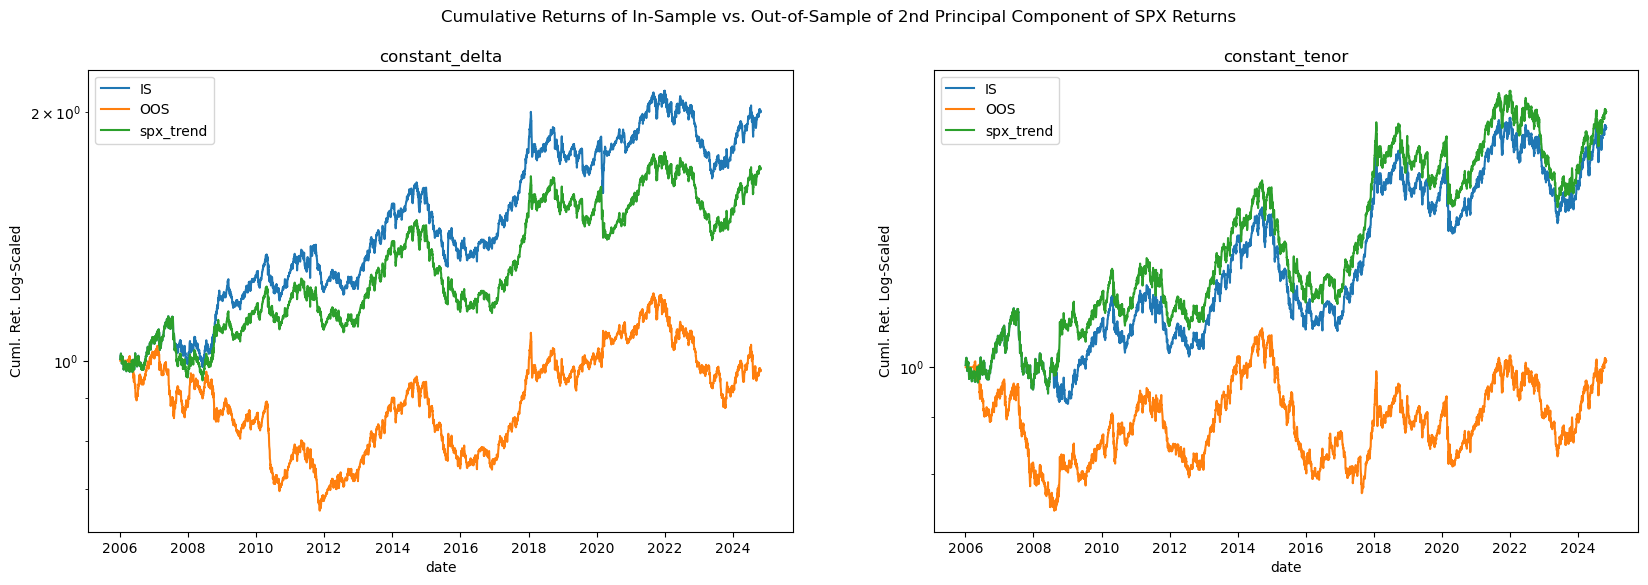

In [38]:
df_longer = (df_pc_rtn.drop(
    columns = ["is_y_pred", "oos_y_pred", "value"]).
    melt(id_vars = ["date", "name"]))

names     = df_longer.name.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(names), figsize = (20,6))

for name, ax in zip(names, axes.flatten()):

    (df_longer.query(
        "name == @name").
        rename(columns = {"variable": ""}).
        pivot(index = "date", columns = "", values = "value").
        rename(columns = {
            "is_signal_rtn" : "IS",
            "oos_signal_rtn": "OOS",
            "vol_rtn"       : "Original Trend"}).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = name))

fig.suptitle("Cumulative Returns of In-Sample vs. Out-of-Sample of 2nd Principal Component of SPX Returns")
plt.show()